In [35]:
%matplotlib inline

In [36]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from sklearn.cluster import KMeans 

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

In [37]:
card_korean = pd.read_csv("./소비패턴_변화_분석_BC카드_유형별_관광업종별/제주특별자치도_제주지역_내국인_유형별_관광_업종_결제데이터_20170216.csv", encoding="ANSI")
card_korean.head()

,지역구분,지역구분_시,지역구분_도심/도심외,지역구분_읍/면/동,관광업종 구분,회원 유형,회원 성별,회원 연령대,회원 거주지,2014-09~2015-08 카드이용금액,2014-09 ~ 2015-08 카드이용건수,2014-09~2015-08 카드이용자수,2015-09~2016-08 카드이용금액,2015-09~2016-08 카드이용건수,2015-09~2016-08 카드이용자수,데이터기준일자
0,제주도,전체,전체,전체,교통,내국인,남,20대 미만,제주,19650725,479,68,29843198,851,197,2017-02-16
1,제주도,전체,전체,전체,교통,내국인,남,20대,제주,2089069468,56192,6528,2711132135,73278,7948,2017-02-16
2,제주도,전체,전체,전체,교통,내국인,남,30대,제주,10164021228,205373,15016,10459317336,220460,15330,2017-02-16
3,제주도,전체,전체,전체,교통,내국인,남,40대,제주,22623678695,367138,20886,20797744658,368599,21333,2017-02-16
4,제주도,전체,전체,전체,교통,내국인,남,50대,제주,24392770471,361576,19359,20730544586,358093,19643,2017-02-16


In [38]:
card_korean.shape

(6110, 16)

In [39]:
card_korean.isnull().sum()

지역구분                        0
지역구분_시                      0
지역구분_도심/도심외                 0
지역구분_읍/면/동                  0
관광업종 구분                     0
회원 유형                       0
회원 성별                       0
회원 연령대                      0
회원 거주지                      0
2014-09~2015-08 카드이용금액      0
2014-09 ~ 2015-08 카드이용건수    0
2014-09~2015-08 카드이용자수      0
2015-09~2016-08 카드이용금액      0
2015-09~2016-08 카드이용건수      0
2015-09~2016-08 카드이용자수      0
데이터기준일자                     0
dtype: int64

In [40]:
for c in card_korean.columns:
    print(f"{c}의 값 목록:")
    print(card_korean[c].unique(), "\n")

지역구분의 값 목록:
['제주도'] 

지역구분_시의 값 목록:
['전체' '서귀포시' '제주시  ' '제주시'] 

지역구분_도심/도심외의 값 목록:
['전체' '도심' '도심 외'] 

지역구분_읍/면/동의 값 목록:
['전체' '건입동' '구좌읍' '남원읍' '노형동' '대륜동' '대정읍' '대천동' '도두동' '동홍동' '봉개동' '삼도1동'
 '삼도2동' '삼양동' '서홍동' '성산읍' '송산동' '아라동' '안덕면' '애월읍' '연동' '영천동' '예래동' '오라동'
 '외도동' '용담1동' '용담2동' '우도면' '이도1동' '이도2동' '이호동' '일도1동' '일도2동' '정방동' '조천읍'
 '중문동' '중앙동' '천지동' '추자면' '표선면' '한경면' '한림읍' '화북동' '효돈동'] 

관광업종 구분의 값 목록:
['교통' '문화/레져' '소매' '쇼핑' '숙박' '식음료' '유흥'] 

회원 유형의 값 목록:
['내국인'] 

회원 성별의 값 목록:
['남' '여'] 

회원 연령대의 값 목록:
['20대 미만' '20대' '30대' '40대' '50대' '60대이상'] 

회원 거주지의 값 목록:
['제주' '한국(제주제외)'] 

2014-09~2015-08 카드이용금액의 값 목록:
[   19650725  2089069468 10164021228 ...    70466940    41606210
    16031700] 

2014-09 ~ 2015-08 카드이용건수의 값 목록:
[   479  56192 205373 ...   4275   6520   3003] 

2014-09~2015-08 카드이용자수의 값 목록:
[   68  6528 15016 ...  3761  2487  1353] 

2015-09~2016-08 카드이용금액의 값 목록:
[   29843198  2711132135 10459317336 ...    96188880    52633750
    19697950] 

2015-09~2016-08 카드이용건수

In [41]:
for c in card_korean.columns:
    if card_korean[c].dtype == int:
        print(f"'{c}' 항목 값의 평균:")
        print(card_korean[c].mean())
        print(card_korean[c].describe())
        print(f"왜도: {card_korean[c].skew()}")
        print(f"첨도: {card_korean[c].kurtosis()}", "\n")

'2014-09~2015-08 카드이용금액' 항목 값의 평균:
558917093.985761
count    6.110000e+03
mean     5.589171e+08
std      2.291066e+09
min      3.050000e+04
25%      1.283825e+07
50%      6.178999e+07
75%      2.470611e+08
max      4.182234e+10
Name: 2014-09~2015-08 카드이용금액, dtype: float64
왜도: 8.875732743392978
첨도: 100.19936038669034 

'2014-09 ~ 2015-08 카드이용건수' 항목 값의 평균:
14569.18690671031
count    6.110000e+03
mean     1.456919e+04
std      7.184378e+04
min      1.000000e+01
25%      2.870000e+02
50%      1.545000e+03
75%      5.981500e+03
max      1.594808e+06
Name: 2014-09 ~ 2015-08 카드이용건수, dtype: float64
왜도: 11.374365436818186
첨도: 160.25344135148305 

'2014-09~2015-08 카드이용자수' 항목 값의 평균:
2971.747790507365
count      6110.000000
mean       2971.747791
std        8882.990535
min          10.000000
25%         156.250000
50%         757.500000
75%        2317.500000
max      156830.000000
Name: 2014-09~2015-08 카드이용자수, dtype: float64
왜도: 8.276007665383322
첨도: 89.51053516877667 

'2015-09~2016-08 카드이용금액' 항

In [42]:
card_chinese = pd.read_csv("./소비패턴_변화_분석_BC카드_유형별_관광업종별/제주특별자치도_제주지역_중국인_관광_업종_결제데이터_20170216.csv", encoding="ANSI")
card_chinese.head()

,지역구분,지역구분_시,지역구분_도심/도심외,지역구분_읍/면/동,관광업종 구분,회원 유형,2014-09~2015-08 카드이용금액,2014-09 ~ 2015-08 카드이용건수,2014-09~2015-08 카드이용자수,2015-09~2016-08 카드이용금액,2015-09~2016-08 카드이용건수,2015-09~2016-08 카드이용자수,데이터기준일자
0,제주도,전체,전체,전체,교통,중국인,175212447,1164,897,131525772,2094,1572,2017-02-16
1,제주도,전체,전체,전체,문화/레져,중국인,51496030372,105713,95402,41562125907,122436,105305,2017-02-16
2,제주도,전체,전체,전체,소매,중국인,202573015771,963687,513522,256067917133,1388534,693308,2017-02-16
3,제주도,전체,전체,전체,쇼핑,중국인,325893391292,1320988,486040,421742999645,2709153,842443,2017-02-16
4,제주도,전체,전체,전체,숙박,중국인,43399696873,21708,16699,38178142342,30450,23311,2017-02-16


In [43]:
for c in card_chinese.columns:
    print(f"{c}의 값 목록:")
    print(card_chinese[c].unique(), "\n")

지역구분의 값 목록:
['제주도'] 

지역구분_시의 값 목록:
['전체' '서귀포시' '제주시'] 

지역구분_도심/도심외의 값 목록:
['전체' '도심' '도심 외'] 

지역구분_읍/면/동의 값 목록:
['전체' '건입동' '구좌읍' '남원읍' '노형동' '대륜동' '대정읍' '대천동' '도두동' '동홍동' '봉개동' '삼도1동'
 '삼도2동' '삼양동' '서홍동' '성산읍' '송산동' '아라동' '안덕면' '애월읍' '연동' '영천동' '예래동' '오라동'
 '외도동' '용담1동' '용담2동' '우도면' '이도1동' '이도2동' '이호동' '일도1동' '일도2동' '정방동' '조천읍'
 '중문동' '중앙동' '천지동' '표선면' '한경면' '한림읍' '화북동' '효돈동'] 

관광업종 구분의 값 목록:
['교통' '문화/레져' '소매' '쇼핑' '숙박' '식음료' '유흥'] 

회원 유형의 값 목록:
['중국인'] 

2014-09~2015-08 카드이용금액의 값 목록:
[   175212447  51496030372 202573015771 325893391292  43399696873
   4386759545     90517370     82590588   3907141300   2907385185
 122820886997  22420424809    672719121      3141460     80705016
    401872440 157071274626 153723337600  18141908477   3091842035
     86472410    592256060     46582090     62883600      5815800
      1537900      1513780      3672800      2911850      4128610
      1344000      1345680      3793350       836600     33607612
       657900  10884166064  13192784013 

Text(0.5, 0.98, '1. 전체 카드 사용 현황')

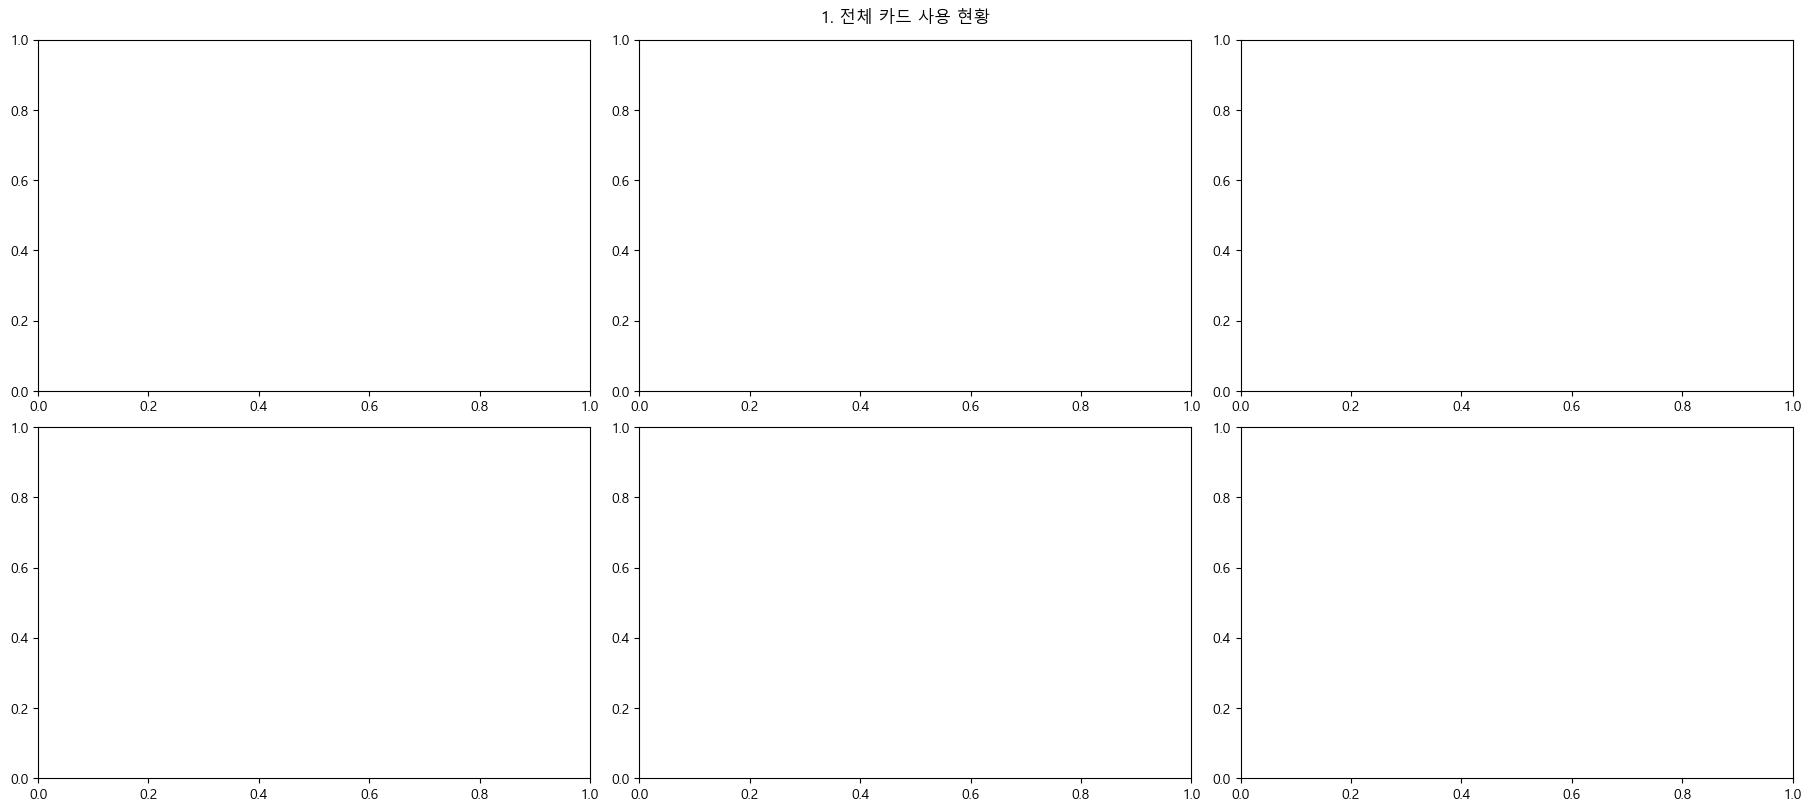

In [44]:
# 1. 전체 소비
# 분류기준 1: 거주지 - 제주도민, 제주도 외 거주 내국인, 중국인
# 분류기준 2: 관광업종 - '교통' '문화/레져' '소매' '쇼핑' '숙박' '식음료' '유흥'

total_k = card_korean[(card_korean['지역구분_시'] == '전체') & (card_korean['지역구분_도심/도심외'] == '전체')].iloc[:, np.r_[4, 8, 9:15]].groupby(['관광업종 구분', '회원 거주지']).sum().reset_index()
total_kj = total_k[total_k['회원 거주지'] == '제주'].iloc[:,np.r_[0, 2:8]]
total_knj = total_k[total_k['회원 거주지'] != '제주'].iloc[:,np.r_[0, 2:8]]

total_c = card_chinese[(card_chinese['지역구분_시'] == '전체') & (card_chinese['지역구분_도심/도심외'] == '전체')].iloc[:, np.r_[4, 6:12]].groupby('관광업종 구분').sum().reset_index()

categories = total_k['관광업종 구분'].unique().tolist()

fig, axs = plt.subplots(2,3, figsize = (18, 8), constrained_layout=True)
width = 0.2
index = np.arange(len(total_kj))
fig.suptitle('1. 전체 카드 사용 현황')

In [45]:
# 1) 제주도민/내국인/중국인 별 2014.09 - 2015.08 카드 총 이용금액 비교

axs[0,0].bar(index-width, total_kj.iloc[:, 1], width, color='green', label='제주도민')
axs[0,0].bar(index, total_knj.iloc[:, 1], width, color='blue', label='제주도민 외 한국인')
axs[0,0].bar(index+width, total_c.iloc[:, 1], width, color='red', label='중국인')
axs[0,0].legend()

axs[0,0].set_xticks(index, categories)
axs[0,0].set_yticklabels([f'{int(y/100000000):,}억 원' for y in axs[0,0].get_yticks()])
axs[0,0].set_xlabel('관광업종 구분')
axs[0,0].set_ylabel('사용 금액')
axs[0,0].set_title('2014.09 - 2015.08 카드 총 사용 금액')



C:\Users\H\AppData\Local\Temp\ipykernel_7608\746937698.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,0].set_yticklabels([f'{int(y/100000000):,}억 원' for y in axs[0,0].get_yticks()])


Text(0.5, 1.0, '2014.09 - 2015.08 카드 총 사용 금액')

In [46]:
# 2) 제주도민/내국인/중국인 별 2014.09 - 2015.08 카드 이용 건수

axs[0,1].bar(index-width, total_kj.iloc[:, 2], width, color='green')
axs[0,1].bar(index, total_knj.iloc[:, 2], width, color='blue')
axs[0,1].bar(index+width, total_c.iloc[:, 2], width, color='red')

axs[0,1].set_xticks(index, categories)
axs[0,1].set_yticklabels([f'{int(y/10000):,}만 건' for y in axs[0,1].get_yticks()])
axs[0,1].set_xlabel('관광업종 구분')
axs[0,1].set_ylabel('이용 건수')
axs[0,1].set_title('2014.09 - 2015.08 카드 총 이용 건수')

C:\Users\H\AppData\Local\Temp\ipykernel_7608\1261914936.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,1].set_yticklabels([f'{int(y/10000):,}만 건' for y in axs[0,1].get_yticks()])


Text(0.5, 1.0, '2014.09 - 2015.08 카드 총 이용 건수')

In [100]:
# 3) 제주도민/내국인/중국인 별 2014.09 - 2015.08 카드 1회당 이용 금액

axs[0,2].bar(index-width, (total_kj.iloc[:, 1] / total_kj.iloc[:, 2]), width, color='green')
axs[0,2].bar(index,(total_knj.iloc[:, 1] / total_knj.iloc[:, 2]), width, color='blue')
axs[0,2].bar(index+width, (total_c.iloc[:, 1] / total_c.iloc[:, 2]), width, color='red')
 
axs[0,2].set_xticks(index, categories)
axs[0,2].set_yticklabels([f'{int(y/10000):,}만 원' for y in axs[0,2].get_yticks()])
axs[0,2].set_xlabel('관광업종 구분')
axs[0,2].set_ylabel('1회당 사용 금액')
axs[0,2].set_title('2014.09 - 2015.08 카드 1회당 사용 금액')

C:\Users\H\AppData\Local\Temp\ipykernel_7608\3158412439.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,2].set_yticklabels([f'{int(y/10000):,}만 원' for y in axs[0,2].get_yticks()])


Text(0.5, 1.0, '2014.09 - 2015.08 카드 1회당 사용 금액')

In [48]:
# 4) 제주도민/내국인/중국인 별 2015.09 - 2016.08 카드 이용금액

axs[1,0].bar(index-width, total_kj.iloc[:, 4], width, color='green')
axs[1,0].bar(index, total_knj.iloc[:, 4], width, color='blue')
axs[1,0].bar(index+width, total_c.iloc[:, 4], width, color='red',)

axs[1,0].set_xticks(index, categories)
axs[1,0].set_yticklabels([f'{int(y/100000000):,}억 원' for y in axs[1,0].get_yticks()])
axs[1,0].set_xlabel('관광업종 구분')
axs[1,0].set_ylabel('사용 금액')
axs[1,0].set_title('2015.09 - 2016.08 카드 총 사용 금액')

C:\Users\H\AppData\Local\Temp\ipykernel_7608\1867783522.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,0].set_yticklabels([f'{int(y/100000000):,}억 원' for y in axs[1,0].get_yticks()])


Text(0.5, 1.0, '2015.09 - 2016.08 카드 총 사용 금액')

In [49]:
# 5) 제주도민/내국인/중국인 별 2015.09 - 2016.08 카드 이용 건수

axs[1,1].bar(index-width, total_kj.iloc[:, 5], width, color='green')
axs[1,1].bar(index, total_knj.iloc[:, 5], width, color='blue')
axs[1,1].bar(index+width, total_c.iloc[:, 5], width, color='red',)

axs[1,1].set_xticks(index, categories)
axs[1,1].set_yticklabels([f'{int(y/10000):,}만 건' for y in axs[1,1].get_yticks()])
axs[1,1].set_xlabel('관광업종 구분')
axs[1,1].set_ylabel('이용 건수')
axs[1,1].set_title('2015.09 - 2016.08 카드 총 이용 건수')

C:\Users\H\AppData\Local\Temp\ipykernel_7608\3978970252.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,1].set_yticklabels([f'{int(y/10000):,}만 건' for y in axs[1,1].get_yticks()])


Text(0.5, 1.0, '2015.09 - 2016.08 카드 총 이용 건수')

In [50]:
# 6) 제주도민/내국인/중국인 별 2015.09 - 2016.08 카드 1회당 이용 금액

axs[1,2].bar(index-width, (total_kj.iloc[:, 4] / total_kj.iloc[:, 5]), width, color='green')
axs[1,2].bar(index,(total_knj.iloc[:, 4] / total_knj.iloc[:, 5]), width, color='blue')
axs[1,2].bar(index+width, (total_c.iloc[:, 4] / total_c.iloc[:, 5]), width, color='red')

axs[1,2].set_xticks(index, categories)
axs[1,2].set_yticklabels([f'{int(y/10000):,}만 원' for y in axs[1,2].get_yticks()])
axs[1,2].set_xlabel('관광업종 구분')
axs[1,2].set_ylabel('1회당 사용 금액')
axs[1,2].set_title('2015.09 - 2016.08 카드 1회당 사용 금액')

C:\Users\H\AppData\Local\Temp\ipykernel_7608\301877713.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1,2].set_yticklabels([f'{int(y/10000):,}만 원' for y in axs[1,2].get_yticks()])


Text(0.5, 1.0, '2015.09 - 2016.08 카드 1회당 사용 금액')

In [32]:
fig.savefig("total.png")

C:\Users\H\AppData\Local\Temp\ipykernel_7608\2794667002.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs2[0,0].set_yticklabels([f'{int(y/100000000):,}억 원' for y in axs2[0,0].get_yticks()])
C:\Users\H\AppData\Local\Temp\ipykernel_7608\2794667002.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs2[0,1].set_yticklabels([f'{int(y/10000):,}만 원' for y in axs2[0,1].get_yticks()])
C:\Users\H\AppData\Local\Temp\ipykernel_7608\2794667002.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs2[1,0].set_yticklabels([f'{int(y/100000000):,}억 원' for y in axs2[1,0].get_yticks()])
C:\Users\H\AppData\Local\Temp\ipykernel_7608\2794667002.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_tic

Text(0.5, 1.0, '2015.09 - 2016.08 카드 1회당 사용 금액')

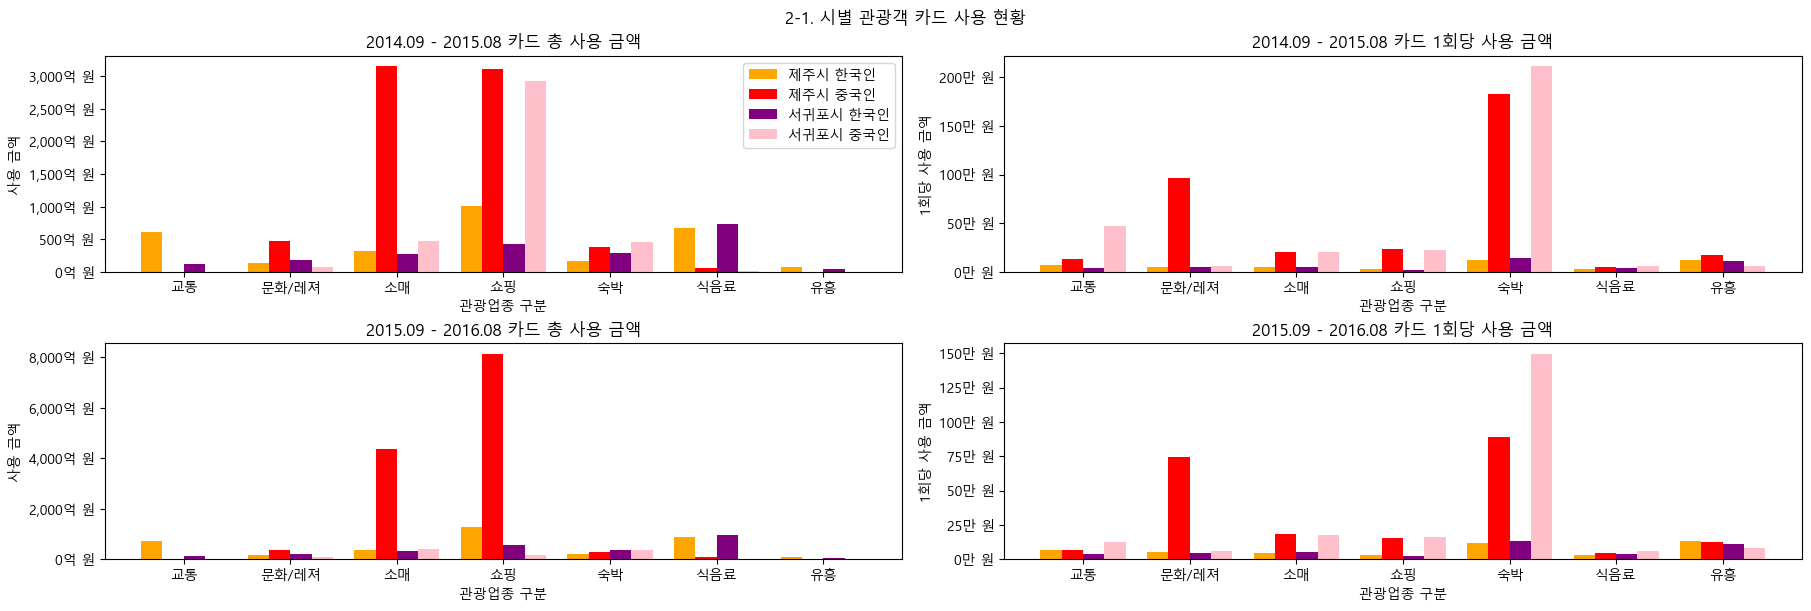

In [51]:
# 2. 지역에 따른 분류

# 1) 제주시/서귀포시

jeju_k = card_korean[(card_korean['지역구분_시'] == '제주시') & (card_korean['회원 거주지'] != '제주')].iloc[:, np.r_[4,9:15]].groupby('관광업종 구분').sum().reset_index()
jeju_c = card_chinese[card_chinese['지역구분_시'] == '제주시'].iloc[:, np.r_[4, 6:12]].groupby('관광업종 구분').sum().reset_index()

suguipo_k = card_korean[(card_korean['지역구분_시'] == '서귀포시') & (card_korean['회원 거주지'] != '제주')].iloc[:, np.r_[4, 9:15]].groupby('관광업종 구분').sum().reset_index()
suguipo_c = card_chinese[card_chinese['지역구분_시'] == '서귀포시'].iloc[:, np.r_[4, 6:12]].groupby('관광업종 구분').sum().reset_index()

fig2, axs2 = plt.subplots(2, 2, figsize = (18, 6), constrained_layout=True)
fig2.suptitle('2-1. 시별 관광객 카드 사용 현황')

axs2[0,0].bar(index - 1.5*width, jeju_k.iloc[:, 1], width, color = 'orange', label = '제주시 한국인')
axs2[0,0].bar(index - 0.5*width, jeju_c.iloc[:, 1], width, color = 'red', label = '제주시 중국인')
axs2[0,0].bar(index + 0.5*width, suguipo_k.iloc[:, 1], width, color = 'purple', label = '서귀포시 한국인')
axs2[0,0].bar(index + 1.5*width, suguipo_c.iloc[:, 1], width, color = 'pink', label = '서귀포시 중국인')
axs2[0,0].set_xticks(index, categories)
axs2[0,0].set_yticklabels([f'{int(y/100000000):,}억 원' for y in axs2[0,0].get_yticks()]) 
axs2[0,0].set_xlabel('관광업종 구분')
axs2[0,0].set_ylabel('사용 금액')
axs2[0,0].set_title('2014.09 - 2015.08 카드 총 사용 금액')

axs2[0,0].legend()

axs2[0,1].bar(index - 1.5*width, (jeju_k.iloc[:, 1] / jeju_k.iloc[:, 2]), width, color = 'orange')
axs2[0,1].bar(index - 0.5*width, (jeju_c.iloc[:, 1] / jeju_c.iloc[:, 2]), width, color = 'red')
axs2[0,1].bar(index + 0.5*width, (suguipo_k.iloc[:, 1] / suguipo_k.iloc[:, 2]), width, color = 'purple')
axs2[0,1].bar(index + 1.5*width, (suguipo_c.iloc[:, 1] / suguipo_c.iloc[:, 2]), width, color = 'pink')
axs2[0,1].set_xticks(index, categories)
axs2[0,1].set_yticklabels([f'{int(y/10000):,}만 원' for y in axs2[0,1].get_yticks()]) 
axs2[0,1].set_xlabel('관광업종 구분')
axs2[0,1].set_ylabel('1회당 사용 금액')
axs2[0,1].set_title('2014.09 - 2015.08 카드 1회당 사용 금액')

axs2[1,0].bar(index - 1.5*width, jeju_k.iloc[:, 4], width, color = 'orange')
axs2[1,0].bar(index - 0.5*width, jeju_c.iloc[:, 4], width, color = 'red')
axs2[1,0].bar(index + 0.5*width, suguipo_k.iloc[:, 4], width, color = 'purple')
axs2[1,0].bar(index + 1.5*width, suguipo_c.iloc[:, 4], width, color = 'pink')
axs2[1,0].set_xticks(index, categories)
axs2[1,0].set_yticklabels([f'{int(y/100000000):,}억 원' for y in axs2[1,0].get_yticks()]) 
axs2[1,0].set_xlabel('관광업종 구분')
axs2[1,0].set_ylabel('사용 금액')
axs2[1,0].set_title('2015.09 - 2016.08 카드 총 사용 금액')

axs2[1,1].bar(index - 1.5*width, (jeju_k.iloc[:, 4] / jeju_k.iloc[:, 5]), width, color = 'orange')
axs2[1,1].bar(index - 0.5*width, (jeju_c.iloc[:, 4] / jeju_c.iloc[:, 5]), width, color = 'red')
axs2[1,1].bar(index + 0.5*width, (suguipo_k.iloc[:, 4] / suguipo_k.iloc[:, 5]), width, color = 'purple')
axs2[1,1].bar(index + 1.5*width, (suguipo_c.iloc[:, 4] / suguipo_c.iloc[:, 5]), width, color = 'pink')
axs2[1,1].set_xticks(index, categories)
axs2[1,1].set_yticklabels([f'{int(y/10000):,}만 원' for y in axs2[1,1].get_yticks()]) 
axs2[1,1].set_xlabel('관광업종 구분')
axs2[1,1].set_ylabel('1회당 사용 금액')
axs2[1,1].set_title('2015.09 - 2016.08 카드 1회당 사용 금액')

In [293]:
fig2.savefig('region_si.png')

C:\Users\hanul\AppData\Local\Temp\ipykernel_20728\4118458650.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs3[0,0].set_yticklabels([f'{int(y/100000000):,}억 원' for y in axs3[0,0].get_yticks()])
C:\Users\hanul\AppData\Local\Temp\ipykernel_20728\4118458650.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs3[0,1].set_yticklabels([f'{int(y/10000):,}만 원' for y in axs3[0,1].get_yticks()])
C:\Users\hanul\AppData\Local\Temp\ipykernel_20728\4118458650.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs3[1,0].set_yticklabels([f'{int(y/100000000):,}억 원' for y in axs3[1,0].get_yticks()])
C:\Users\hanul\AppData\Local\Temp\ipykernel_20728\4118458650.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks

Text(0.5, 1.0, '2015.09 - 2016.08 카드 1회당 사용 금액')

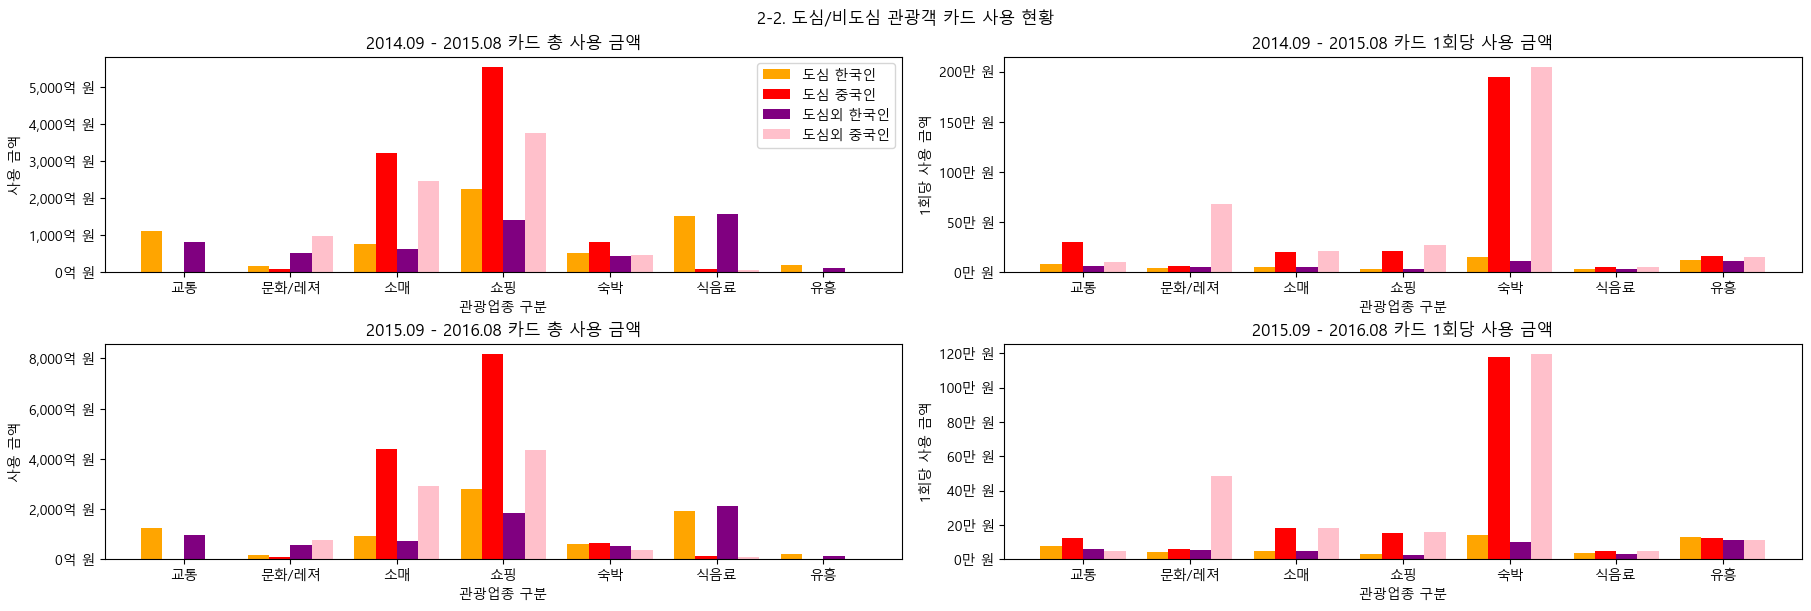

In [294]:
# 2) 도심/도심 외

urban_k = card_korean[(card_korean['지역구분_도심/도심외'] == '도심') & (card_korean['회원 거주지'] != '제주')].iloc[:, np.r_[4,9:15]].groupby('관광업종 구분').sum().reset_index()
urban_c = card_chinese[card_chinese['지역구분_도심/도심외'] == '도심'].iloc[:, np.r_[4, 6:12]].groupby('관광업종 구분').sum().reset_index()
rural_k = card_korean[(card_korean['지역구분_도심/도심외'] != '도심') & (card_korean['회원 거주지'] != '제주')].iloc[:, np.r_[4,9:15]].groupby('관광업종 구분').sum().reset_index()
rural_c = card_chinese[card_chinese['지역구분_도심/도심외'] != '도심'].iloc[:, np.r_[4, 6:12]].groupby('관광업종 구분').sum().reset_index()

fig3, axs3 = plt.subplots(2, 2, figsize = (18, 6), constrained_layout=True)
fig3.suptitle('2-2. 도심/비도심 관광객 카드 사용 현황')

axs3[0,0].bar(index - 1.5*width, urban_k.iloc[:, 1], width, color = 'orange', label = '도심 한국인')
axs3[0,0].bar(index - 0.5*width, urban_c.iloc[:, 1], width, color = 'red', label = '도심 중국인')
axs3[0,0].bar(index + 0.5*width, rural_k.iloc[:, 1], width, color = 'purple', label = '도심외 한국인')
axs3[0,0].bar(index + 1.5*width, rural_c.iloc[:, 1], width, color = 'pink', label = '도심외 중국인')
axs3[0,0].set_xticks(index, categories)
axs3[0,0].set_yticklabels([f'{int(y/100000000):,}억 원' for y in axs3[0,0].get_yticks()]) 
axs3[0,0].set_xlabel('관광업종 구분')
axs3[0,0].set_ylabel('사용 금액')
axs3[0,0].set_title('2014.09 - 2015.08 카드 총 사용 금액')

axs3[0,0].legend()

axs3[0,1].bar(index - 1.5*width, (urban_k.iloc[:, 1] / urban_k.iloc[:, 2]), width, color = 'orange')
axs3[0,1].bar(index - 0.5*width, (urban_c.iloc[:, 1] / urban_c.iloc[:, 2]), width, color = 'red')
axs3[0,1].bar(index + 0.5*width, (rural_k.iloc[:, 1] / rural_k.iloc[:, 2]), width, color = 'purple')
axs3[0,1].bar(index + 1.5*width, (rural_c.iloc[:, 1] / rural_c.iloc[:, 2]), width, color = 'pink')
axs3[0,1].set_xticks(index, categories)
axs3[0,1].set_yticklabels([f'{int(y/10000):,}만 원' for y in axs3[0,1].get_yticks()]) 
axs3[0,1].set_xlabel('관광업종 구분')
axs3[0,1].set_ylabel('1회당 사용 금액')
axs3[0,1].set_title('2014.09 - 2015.08 카드 1회당 사용 금액')

axs3[1,0].bar(index - 1.5*width, urban_k.iloc[:, 4], width, color = 'orange')
axs3[1,0].bar(index - 0.5*width, urban_c.iloc[:, 4], width, color = 'red')
axs3[1,0].bar(index + 0.5*width, rural_k.iloc[:, 4], width, color = 'purple')
axs3[1,0].bar(index + 1.5*width, rural_c.iloc[:, 4], width, color = 'pink')
axs3[1,0].set_xticks(index, categories)
axs3[1,0].set_yticklabels([f'{int(y/100000000):,}억 원' for y in axs3[1,0].get_yticks()]) 
axs3[1,0].set_xlabel('관광업종 구분')
axs3[1,0].set_ylabel('사용 금액')
axs3[1,0].set_title('2015.09 - 2016.08 카드 총 사용 금액')

axs3[1,1].bar(index - 1.5*width, (urban_k.iloc[:, 4] / urban_k.iloc[:, 5]), width, color = 'orange')
axs3[1,1].bar(index - 0.5*width, (urban_c.iloc[:, 4] / urban_c.iloc[:, 5]), width, color = 'red')
axs3[1,1].bar(index + 0.5*width, (rural_k.iloc[:, 4] / rural_k.iloc[:, 5]), width, color = 'purple')
axs3[1,1].bar(index + 1.5*width, (rural_c.iloc[:, 4] / rural_c.iloc[:, 5]), width, color = 'pink')
axs3[1,1].set_xticks(index, categories)
axs3[1,1].set_yticklabels([f'{int(y/10000):,}만 원' for y in axs3[1,1].get_yticks()]) 
axs3[1,1].set_xlabel('관광업종 구분')
axs3[1,1].set_ylabel('1회당 사용 금액')
axs3[1,1].set_title('2015.09 - 2016.08 카드 1회당 사용 금액')

In [296]:
fig3.savefig('region_urban_or_not.png')

C:\Users\hanul\AppData\Local\Temp\ipykernel_20728\3388092303.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs4[0].set_yticklabels(f'{int(y/100000000):,}억 원' for y in axs4[0].get_yticks())
C:\Users\hanul\AppData\Local\Temp\ipykernel_20728\3388092303.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs4[1].set_yticklabels(f'{int(y/10000)}만 원' for y in axs4[1].get_yticks())
C:\Users\hanul\AppData\Local\Temp\ipykernel_20728\3388092303.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs4[2].set_yticklabels(f'{int(y/10000)}만 원' for y in axs4[2].get_yticks())
C:\Users\hanul\AppData\Local\Temp\ipykernel_20728\3388092303.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() o

[Text(0, 0.0, '0만 원'),
 Text(0, 250000.0, '25만 원'),
 Text(0, 500000.0, '50만 원'),
 Text(0, 750000.0, '75만 원'),
 Text(0, 1000000.0, '100만 원'),
 Text(0, 1250000.0, '125만 원'),
 Text(0, 1500000.0, '150만 원')]

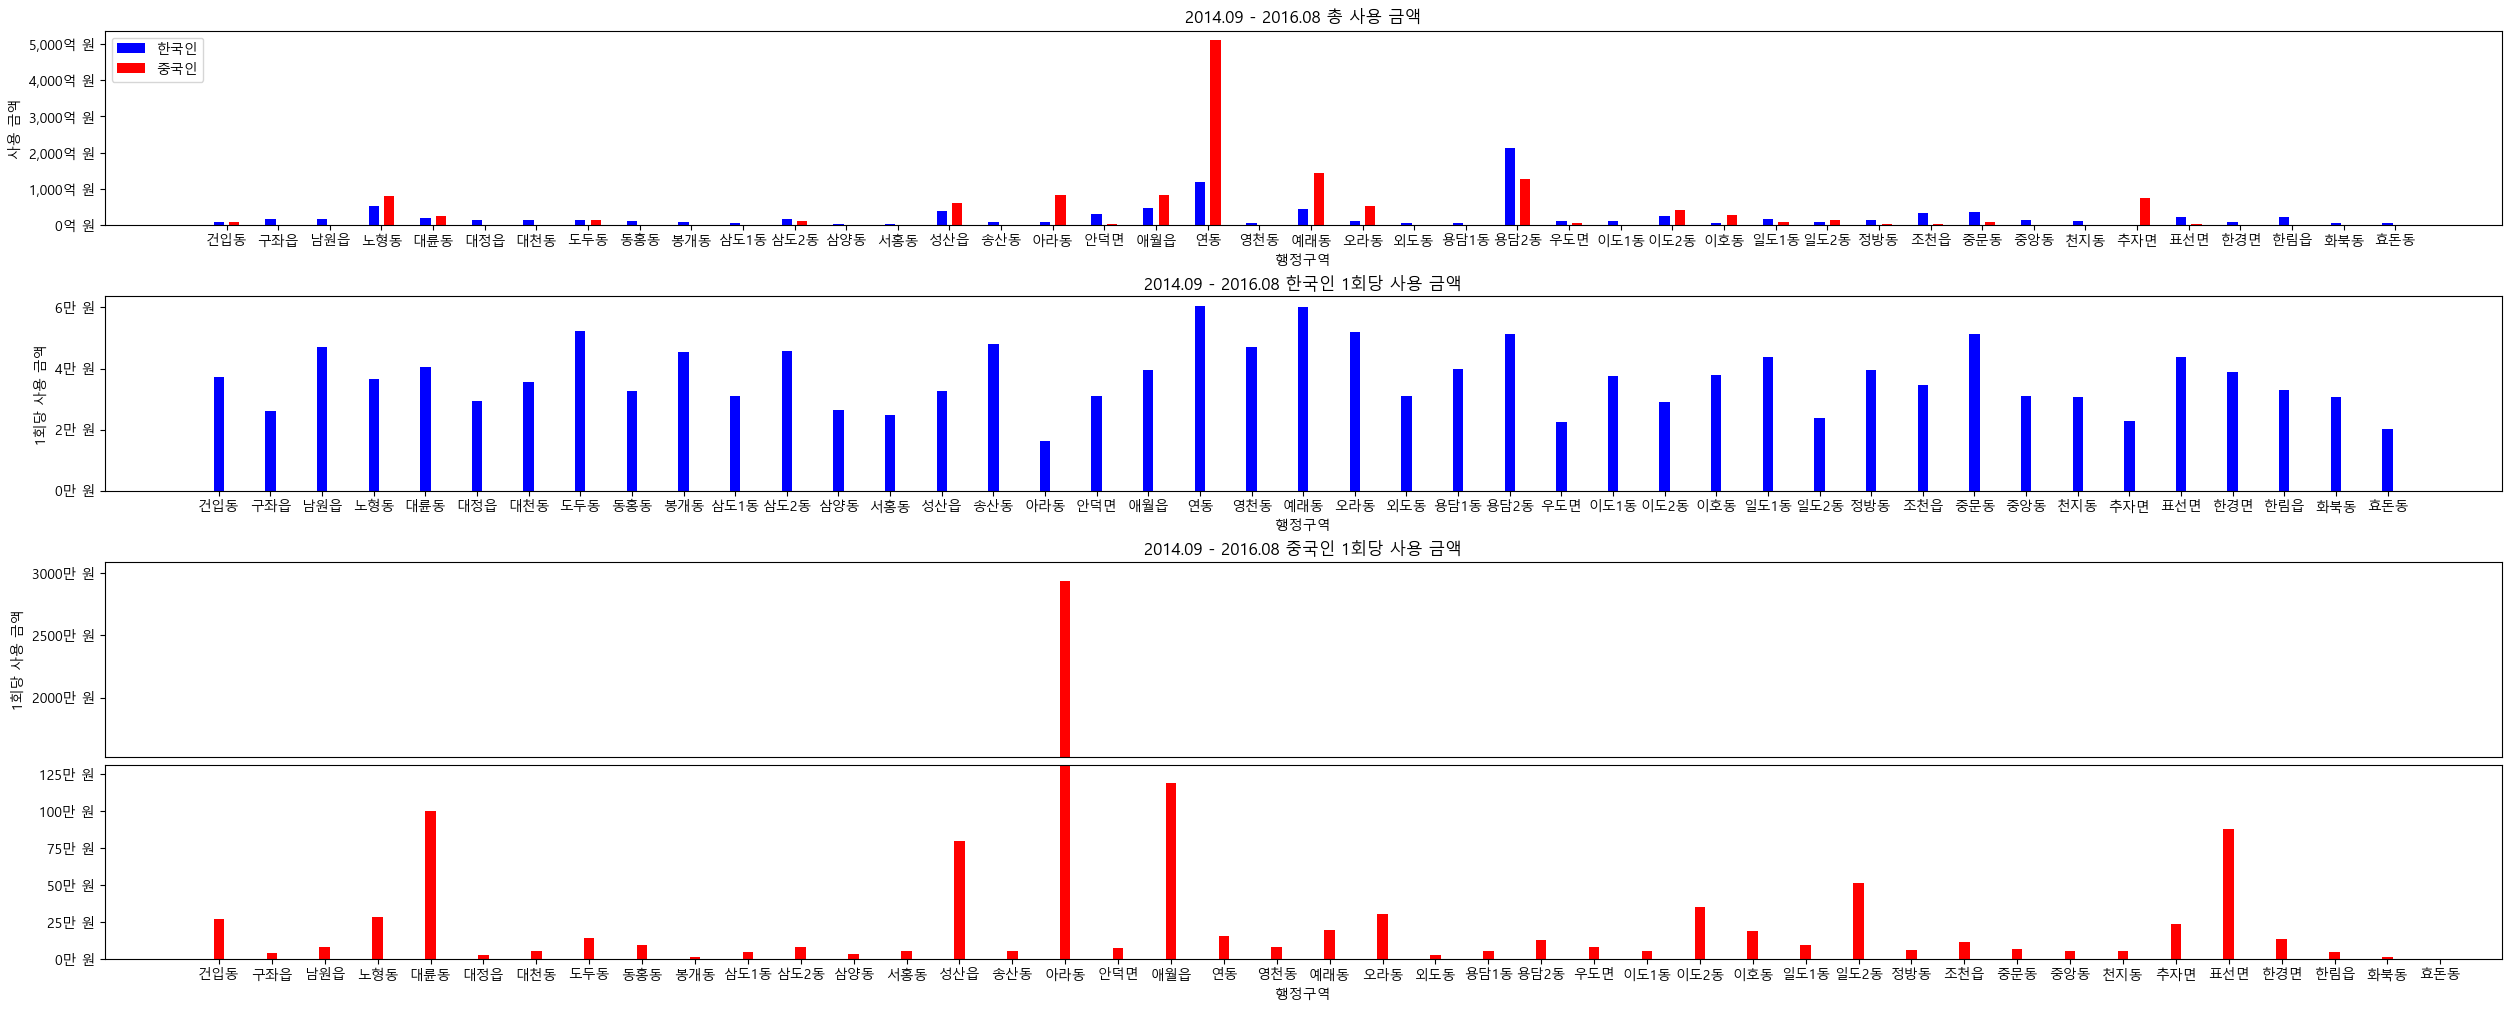

In [297]:
# 3) 행정구역

region_k = card_korean[(card_korean['회원 거주지'] != '제주') & (card_korean['지역구분_읍/면/동'] != '전체')].iloc[:, np.r_[3:5, 9:15]].groupby('지역구분_읍/면/동').sum().reset_index()
regions = region_k['지역구분_읍/면/동']
region_c = card_chinese[card_chinese['지역구분_읍/면/동'] != '전체'].iloc[:, np.r_[3:5, 6:12]].groupby('지역구분_읍/면/동',).sum().reset_index()
for r in regions:
    if r not in region_c['지역구분_읍/면/동']:
        region_c = pd.concat([region_c, pd.DataFrame([{'지역구분_읍/면/동':r}])], ignore_index=True)
        region_c.fillna(0)
        break

fig4, axs4 = plt.subplots(4, 1, figsize = (25, 10), constrained_layout=True)
fig.suptitle('2-3. 행정구역별 관광객 카드 사용 현황')
index4 = np.arange(len(region_k['지역구분_읍/면/동']))
width4 = 0.3

axs4[0].bar(index4 - 0.5 * width4, region_k.iloc[:, 2] + region_k.iloc[:, 5], width, color = 'blue', label = '한국인')
axs4[0].bar(index4 + 0.5 * width4, region_c.iloc[:, 2] + region_c.iloc[:, 5], width,color = 'red', label = '중국인')
axs4[0].set_xticks(index4, regions)
axs4[0].set_yticklabels(f'{int(y/100000000):,}억 원' for y in axs4[0].get_yticks())
axs4[0].set_xlabel('행정구역')
axs4[0].set_ylabel('사용 금액')
axs4[0].set_title('2014.09 - 2016.08 총 사용 금액')
axs4[0].legend()

# 1회당 결제 금액은 두 집단 차이가 너무 커서 별개의 그래프로 그림

axs4[1].bar(index4, (region_k.iloc[:, 2] + region_k.iloc[:, 5]) / (region_k.iloc[:, 3] + region_k.iloc[:, 6]), width, color = 'blue')
axs4[1].set_ylabel('1회당 사용 금액')
axs4[1].set_xlabel('행정구역')
axs4[1].set_title('2014.09 - 2016.08 한국인 1회당 사용 금액')
axs4[1].set_xticks(index4, regions)
axs4[1].set_yticklabels(f'{int(y/10000)}만 원' for y in axs4[1].get_yticks())

# 한 값만 커서 broken y axis 사용; 전체 결제 금액 합이므로 outlier 처리는 적합하지 않음

once_c = (region_c.iloc[:, 2] + region_c.iloc[:, 5]) / (region_c.iloc[:, 3] + region_c.iloc[:, 6])
devider = once_c.nlargest(2).iloc[-1]

axs4[2].bar(index4, once_c, width, color = 'red')
axs4[2].set_ylabel('1회당 사용 금액')
axs4[2].set_title('2014.09 - 2016.08 중국인 1회당 사용 금액')
axs4[2].set_ylim((devider + max(once_c)) / 2, max(once_c) * 1.05)
axs4[2].set_yticklabels(f'{int(y/10000)}만 원' for y in axs4[2].get_yticks())
axs4[2].axes.xaxis.set_visible(False)

axs4[3].bar(index4, once_c, width, color = 'red')
axs4[3].set_ylim(0, devider * 1.1)
axs4[3].set_xlabel('행정구역')
axs4[3].set_xticks(index4, regions)
axs4[3].set_yticklabels(f'{int(y/10000)}만 원' for y in axs4[3].get_yticks())

In [299]:
fig4.savefig('region_per_area.png')

C:\Users\hanul\AppData\Local\Temp\ipykernel_20728\2022702169.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs5[0].set_yticklabels(f'{int(y/10000)}만 원' for y in axs5[0].get_yticks())
C:\Users\hanul\AppData\Local\Temp\ipykernel_20728\2022702169.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs5[1].set_yticklabels(f'{int(y/10000)}만 명' for y in axs5[1].get_yticks())
C:\Users\hanul\AppData\Local\Temp\ipykernel_20728\2022702169.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs5[2].set_yticklabels(f'{int(y/10000)}만 원' for y in axs5[2].get_yticks())


Text(0.5, 1.0, '2014.09 - 2016.08 카드 1회당 사용 금액')

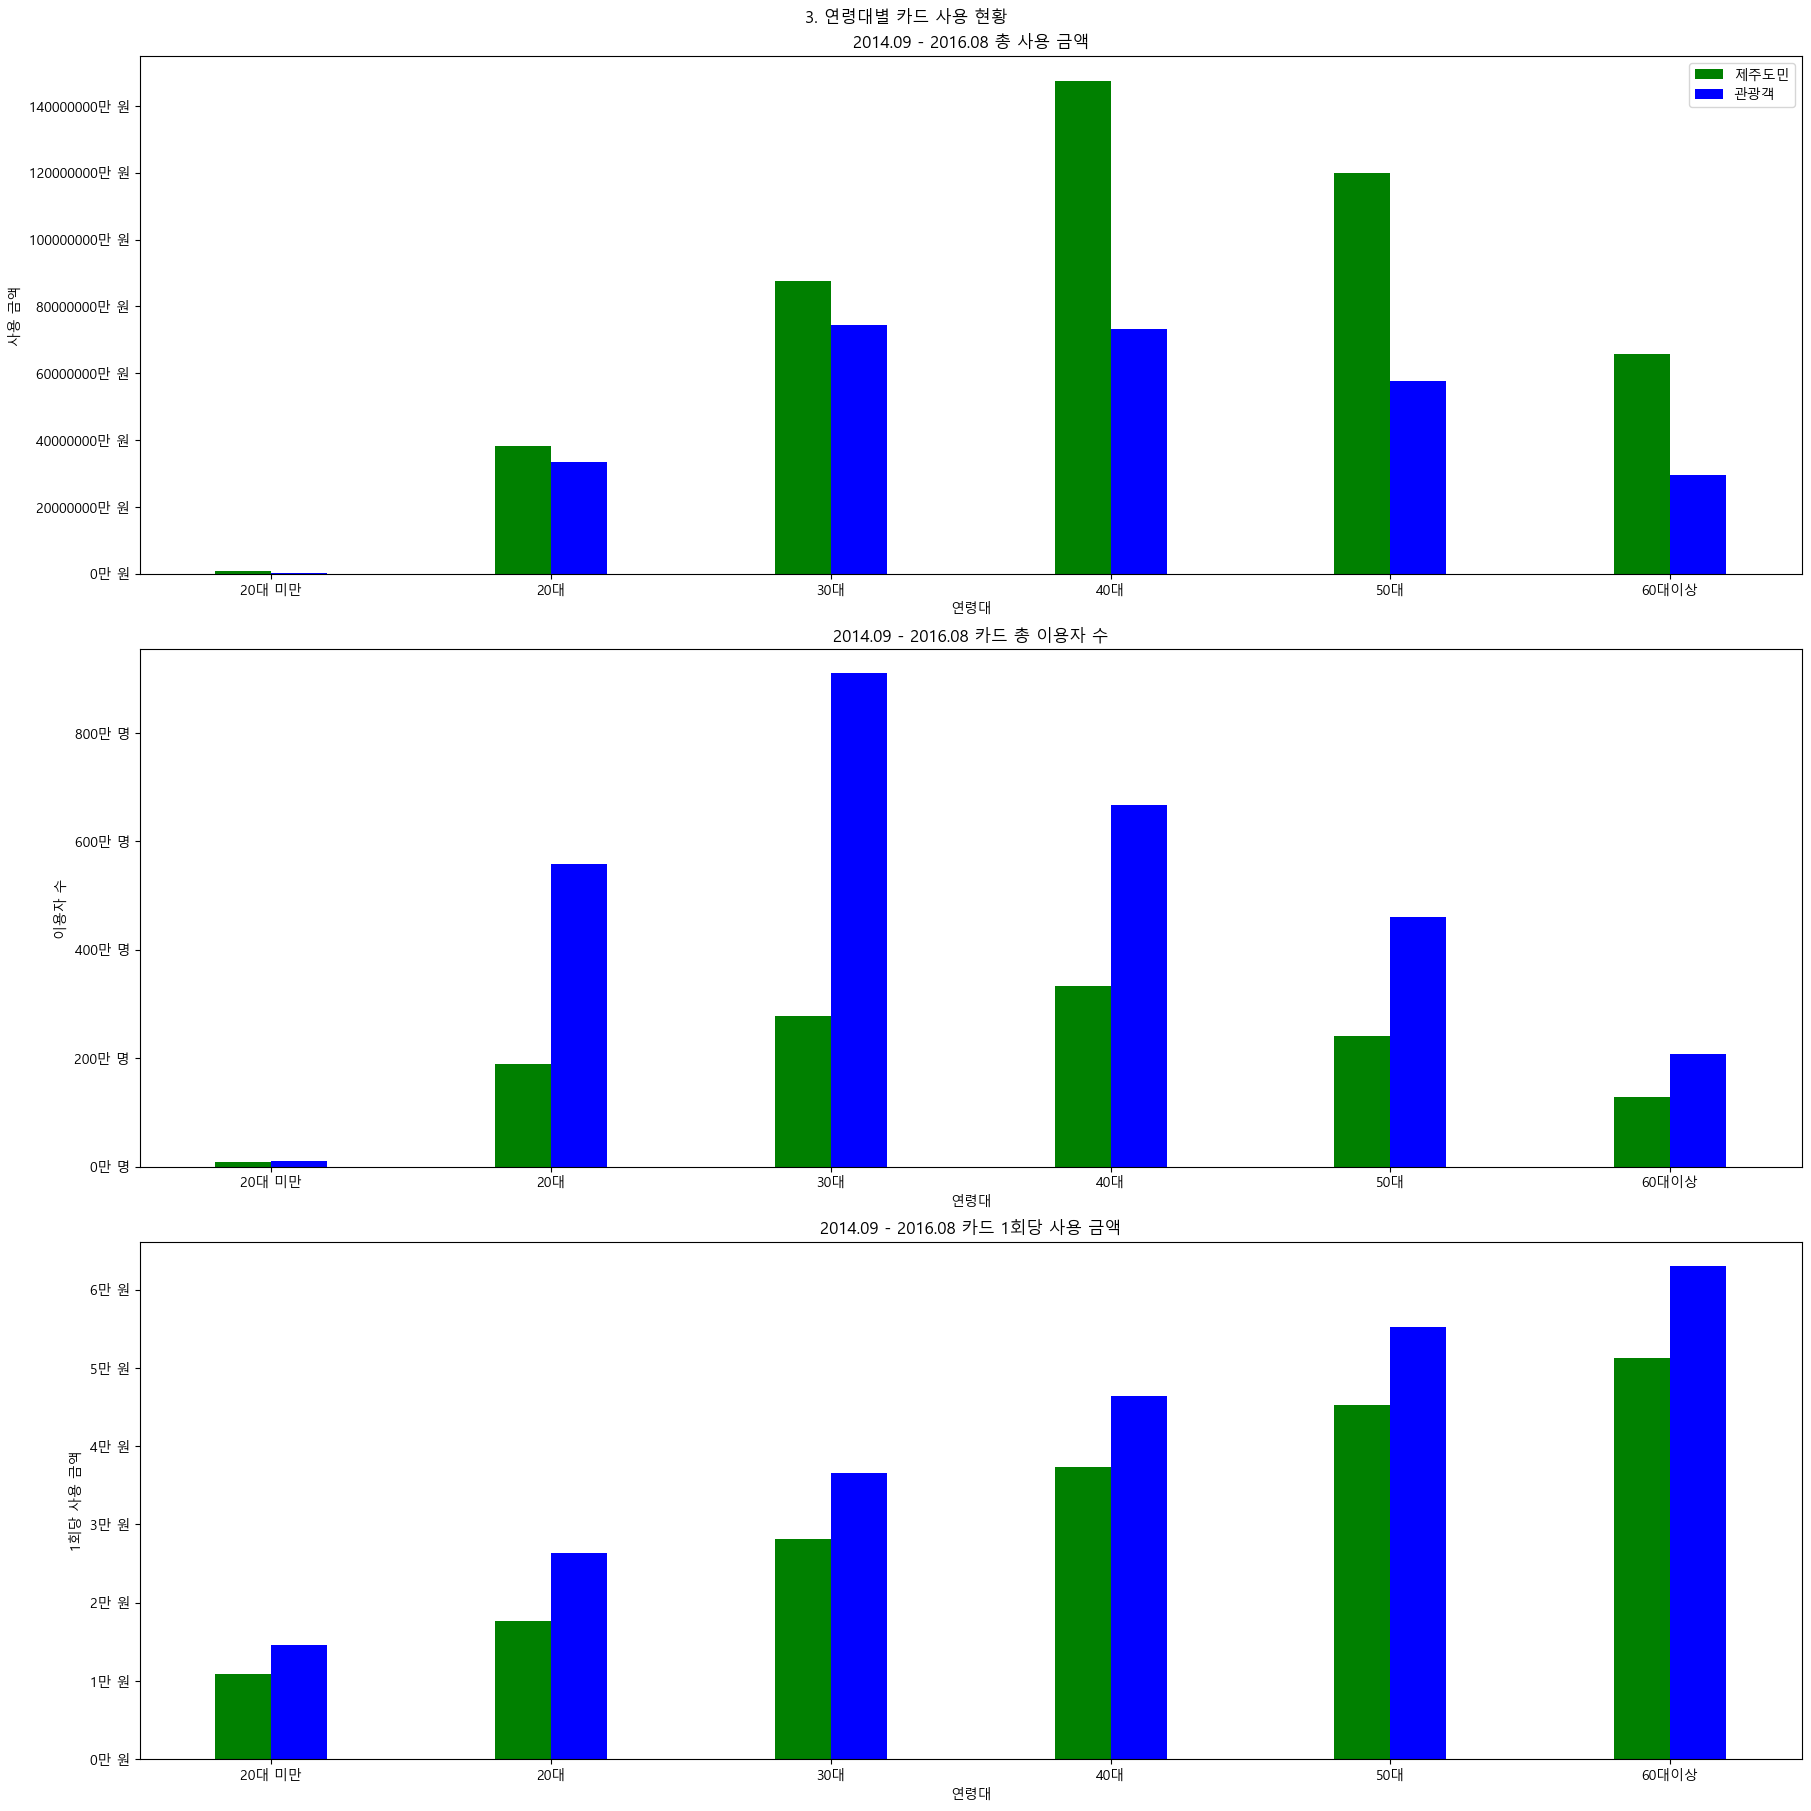

In [322]:
# 4. 연령에 따른 분석
# 연령, 성별별 자료가 제공되는 것은 내국인 뿐이므로 내국인 자료로만 진행

age_jeju = card_korean[card_korean['회원 거주지'] == '제주'].iloc[:, np.r_[7, 9:15]].groupby('회원 연령대').sum().reset_index()
age_tourist = card_korean[card_korean['회원 거주지'] != '제주'].iloc[:, np.r_[7, 9:15]].groupby('회원 연령대').sum().reset_index()

ages = pd.DataFrame({'회원 연령대':['20대 미만', '20대', '30대', '40대', '50대', '60대이상']})

age_jeju['회원 연령대'] = pd.Categorical(age_jeju['회원 연령대'], categories = ages['회원 연령대'], ordered = True)
age_jeju = age_jeju.sort_values('회원 연령대')
age_tourist['회원 연령대'] = pd.Categorical(age_tourist['회원 연령대'], categories = ages['회원 연령대'], ordered = True)
age_tourist = age_tourist.sort_values('회원 연령대')

fig5, axs5 = plt.subplots(3, 1, figsize = (18, 18), constrained_layout=True)
index5 = np.arange(len(ages))
fig5.suptitle('3. 연령대별 카드 사용 현황')

axs5[0].bar(index5 - 0.5 * width, age_jeju.iloc[:, 1] + age_jeju.iloc[:, 4], width, color = 'green', label = '제주도민')
axs5[0].bar(index5 + 0.5 * width, age_tourist.iloc[:, 1] + age_tourist.iloc[:, 4], width, color = 'blue', label = '관광객')
axs5[0].legend()
axs5[0].set_xticks(index5, ages['회원 연령대'])
axs5[0].set_yticklabels(f'{int(y/10000)}만 원' for y in axs5[0].get_yticks())
axs5[0].set_xlabel('연령대')
axs5[0].set_ylabel('사용 금액')
axs5[0].set_title('2014.09 - 2016.08 총 사용 금액')

axs5[1].bar(index5 - 0.5 * width, age_jeju.iloc[:, 3] + age_jeju.iloc[:, 6], width, color = 'green')
axs5[1].bar(index5 + 0.5 * width, age_tourist.iloc[:, 3] + age_tourist.iloc[:, 6], width, color = 'blue')
axs5[1].set_xticks(index5, ages['회원 연령대'])
axs5[1].set_yticklabels(f'{int(y/10000)}만 명' for y in axs5[1].get_yticks())
axs5[1].set_xlabel('연령대')
axs5[1].set_ylabel('이용자 수')
axs5[1].set_title('2014.09 - 2016.08 카드 총 이용자 수')

axs5[2].bar(index5 - 0.5 * width, (age_jeju.iloc[:, 1] + age_jeju.iloc[:, 4]) / (age_jeju.iloc[:, 2] + age_jeju.iloc[:, 5]), width, color = 'green')
axs5[2].bar(index5 + 0.5 * width, (age_tourist.iloc[:, 1] + age_tourist.iloc[:, 4]) / (age_tourist.iloc[:, 2] + age_tourist.iloc[:, 5]), width, color = 'blue')
axs5[2].set_xticks(index5, ages['회원 연령대'])
axs5[2].set_yticklabels(f'{int(y/10000)}만 원' for y in axs5[2].get_yticks())
axs5[2].set_xlabel('연령대')
axs5[2].set_ylabel('1회당 사용 금액')
axs5[2].set_title('2014.09 - 2016.08 카드 1회당 사용 금액')

In [323]:
fig5.savefig('age.png')

C:\Users\hanul\AppData\Local\Temp\ipykernel_20728\849587619.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs6[0].set_yticklabels(f'{int(y/100000000)}억 원' for y in axs6[0].get_yticks())
C:\Users\hanul\AppData\Local\Temp\ipykernel_20728\849587619.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs6[1].set_yticklabels(f'{int(y/10000)}만 명' for y in axs6[1].get_yticks())


Text(0.5, 1.0, '2014.09 - 2016.08 카드 총 이용자 수')

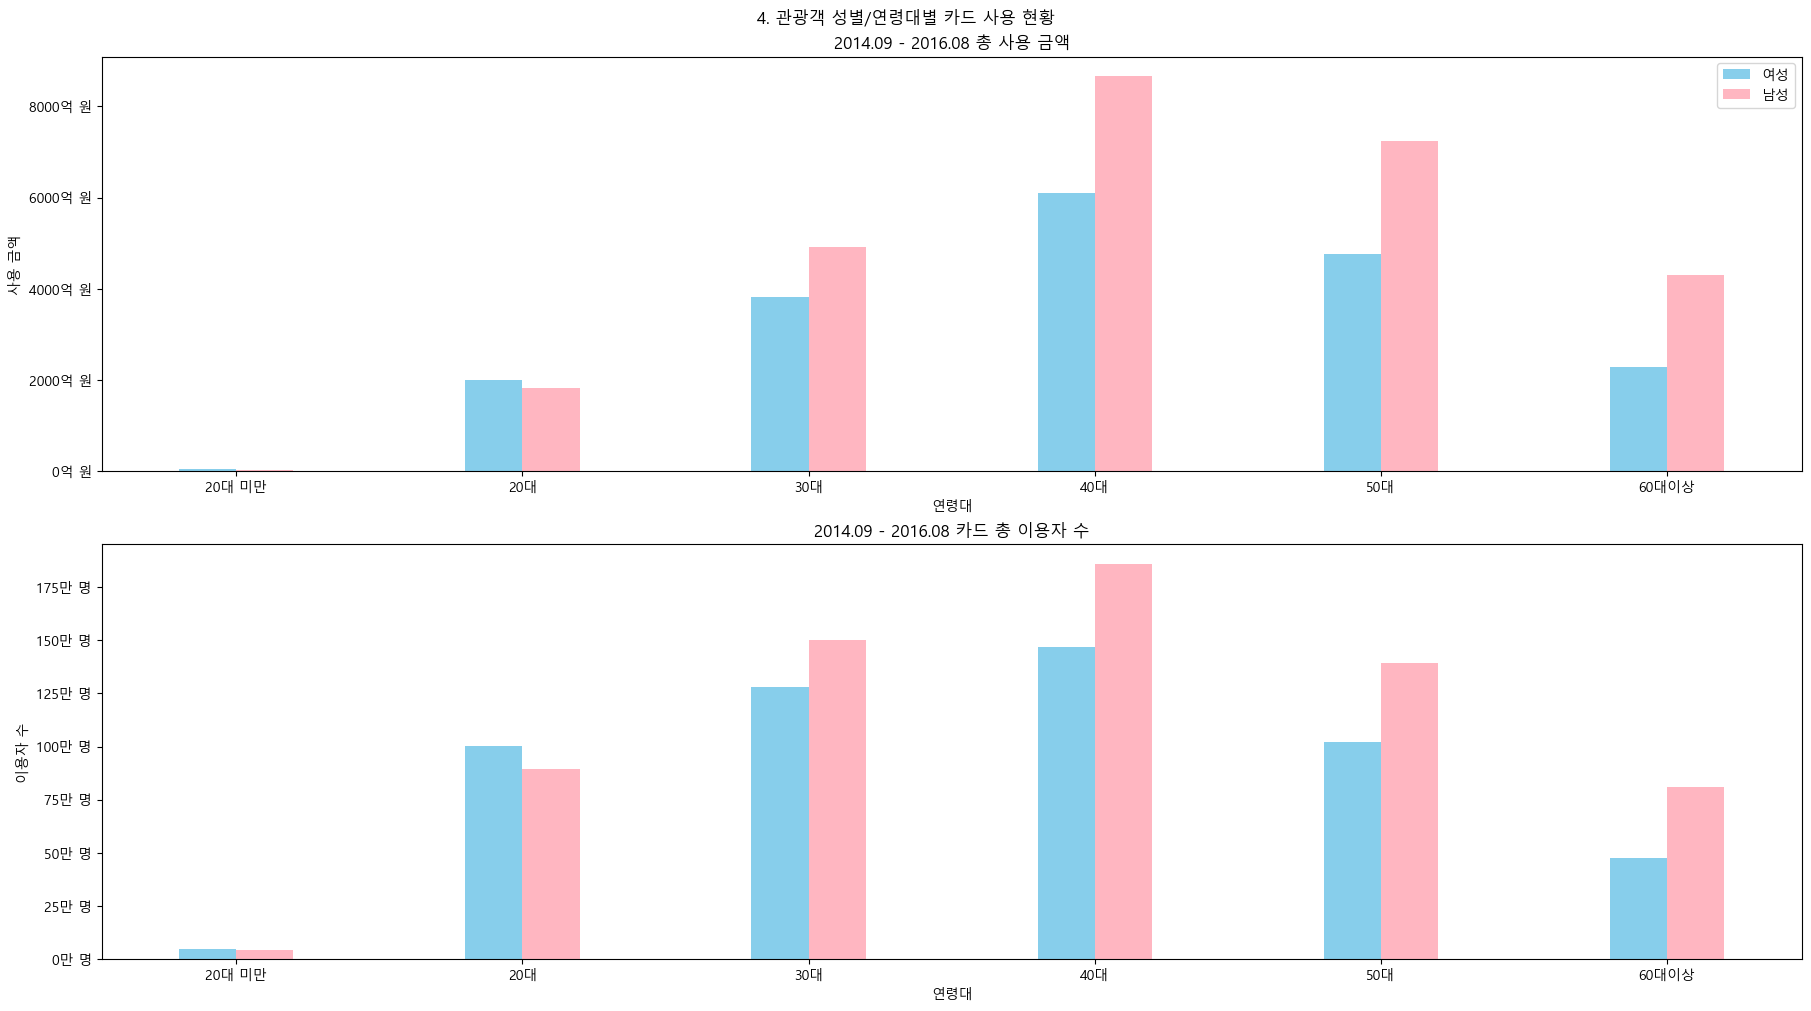

In [324]:
# 5. 연령대 & 성별

group_jeju = card_korean[card_korean['회원 거주지'] == '제주'].iloc[:, np.r_[6:8, 9:15]].groupby(['회원 연령대', '회원 성별']).sum().reset_index()
group_tourist = card_korean[card_korean['회원 거주지'] != '제주'].iloc[:, np.r_[6:8, 9:15]].groupby(['회원 연령대', '회원 성별']).sum().reset_index()

group_jeju['회원 연령대'] = pd.Categorical(group_jeju['회원 연령대'], categories = ages['회원 연령대'], ordered = True)
group_jeju = group_jeju.sort_values('회원 연령대')
group_tourist['회원 연령대'] = pd.Categorical(group_tourist['회원 연령대'], categories = ages['회원 연령대'], ordered = True)
group_tourist = group_tourist.sort_values('회원 연령대')

fig6, axs6 = plt.subplots(2, 1, figsize = (18, 10), constrained_layout=True)
fig6.suptitle('4. 관광객 성별/연령대별 카드 사용 현황')

woman = group_jeju[group_jeju['회원 성별'] == '여']
man = group_jeju[group_jeju['회원 성별'] != '여']

axs6[0].bar(index5 - 0.5 * width, woman.iloc[:,2] + woman.iloc[:,5], width, color = 'skyblue', label = '여성')
axs6[0].bar(index5 + 0.5 * width, man.iloc[:,2] + man.iloc[:,5], width, color = 'lightpink', label = '남성')
axs6[0].legend()
axs6[0].set_xticks(index5, ages['회원 연령대'])
axs6[0].set_xlabel('연령대')
axs6[0].set_yticklabels(f'{int(y/100000000)}억 원' for y in axs6[0].get_yticks())
axs6[0].set_ylabel('사용 금액')
axs6[0].set_title('2014.09 - 2016.08 총 사용 금액')

axs6[1].bar(index5 - 0.5 * width, woman.iloc[:,4] + woman.iloc[:,7], width, color = 'skyblue')
axs6[1].bar(index5 + 0.5 * width, man.iloc[:,4] + man.iloc[:,7], width, color = 'lightpink')
axs6[1].set_xticks(index5, ages['회원 연령대'])
axs6[1].set_xlabel('연령대')
axs6[1].set_yticklabels(f'{int(y/10000)}만 명' for y in axs6[1].get_yticks())
axs6[1].set_ylabel('이용자 수')
axs6[1].set_title('2014.09 - 2016.08 카드 총 이용자 수')

In [304]:
fig6.savefig('age_and_gender.png')